In [1]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#loading dataset
df = sns.load_dataset("titanic")


In [3]:
# the next block of code is mainly for exploring data

# show first rows
df.head()

# general info
df.info()

# check missing values
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Data Cleaning

- The `age` column had missing values, so we filled them using the median.
- The `deck` column had too many missing values, so it was removed because it would not add useful information to the analysis.

These steps help make the data cleaner and easier to work with.


In [4]:
# fill missing age
df["age"] = df["age"].fillna(df["age"].median())

# drop deck column
df = df.drop(columns=["deck"])

## Exploratory Data Analysis (EDA)

Before creating visualizations, we explored the dataset to understand its structure and key patterns.

- We checked the distribution of key variables such as survival, gender, and class.
- We used value counts to see how many passengers survived or not.
- We explored relationships between variables using basic statistics.

This step helps us understand the data before visualizing it.

In [5]:
# Check how many people survived and died
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [6]:
# Calculate overall survival rate (percentage of people who survived)
survival_rate=df["survived"].mean()

In [7]:
# Check number of males and females
df["sex"].value_counts()
# Check survival rate for each gender
sex_survival=df.groupby("sex")["survived"].mean()

In [8]:
# Check number of passengers in each class
df["class"].value_counts()
# Check survival rate for each class
df.groupby("class")["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

In [9]:
# Show basic statistics (age, fare, etc.)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
#  Relationship analysis
# Compare average age between survivors and non-survivors
df.groupby("survived")["age"].mean()

survived
0    30.028233
1    28.291433
Name: age, dtype: float64

In [11]:
# Check survival rate based on both gender and class
df.groupby(["sex", "class"])["survived"].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

## Data Visualisation

In this section, we use visualisations to explore patterns and relationships in the data.

The goal is to better understand the factors that affected survival on the Titanic, such as gender, class, and age.

Each plot includes a short explanation to describe the key insights.

**plot 1 :OVERALL_SURVIVAL**

This plot shows the number of passengers who survived and those who did not. It is clear that more passengers did not survive than those who survived.

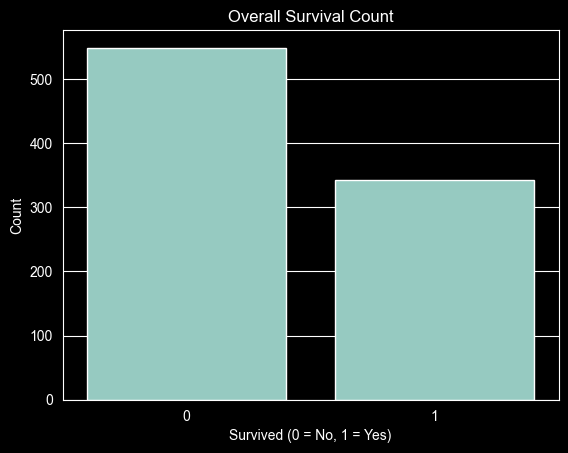

In [12]:
sns.countplot(data=df, x="survived")
plt.title("Overall Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

***plot 2 SURVIVAL BY GENDER***

This plot shows survival based on gender. It is clear that females had a much higher survival rate compared to males.

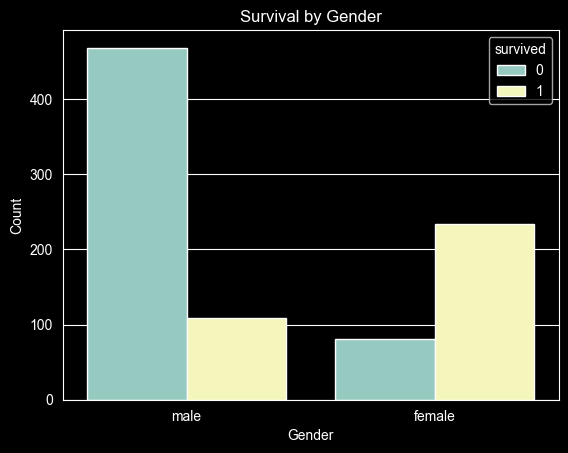

In [13]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

 **Plot 3: Survival Rate by Passenger Class**

This plot shows that passengers in higher classes had better chances of survival, especially those in first class.

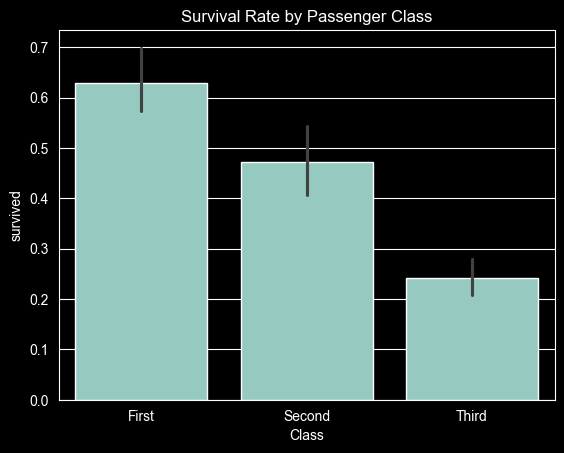

In [14]:
sns.barplot(data=df, x="class", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Class")
plt.ylabel("survived")
plt.show()

**Plot 4 : The distribution of age vs survival**

This plot shows the distribution of passengers' ages separated by survival status. It suggests that younger passengers, especially children, had a higher chance of survival compared to adults and older passengers.

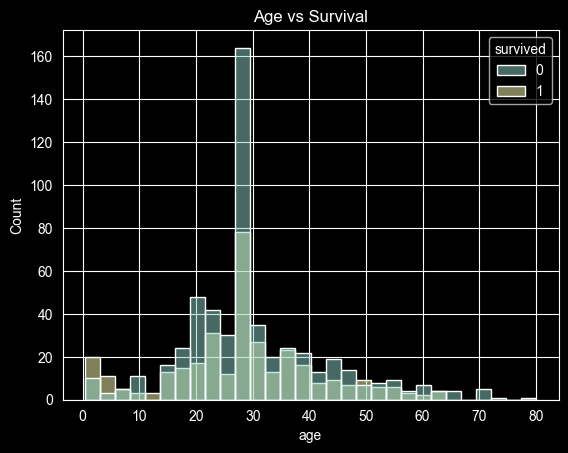

In [15]:
sns.histplot(data=df, x="age", hue="survived", bins=30)
plt.title("Age vs Survival")
plt.show()

**plot 5 : Survival Rate by Sex (Relational Analysis)**

This plot shows the relationship between passenger sex and survival rate on the Titanic. It compares the average survival rate of male and female passengers, highlighting that survival chances were different across genders. This helps us understand how sex influenced survival probability.


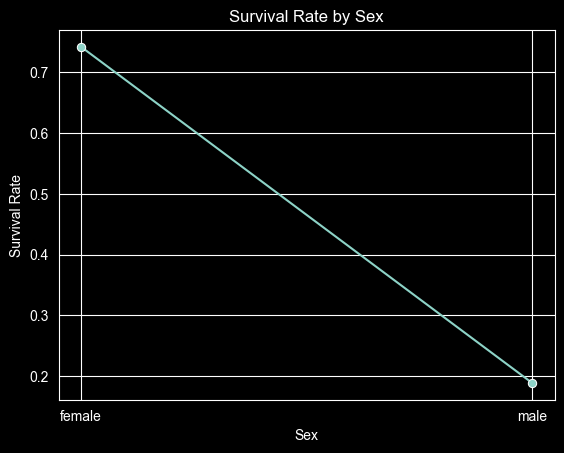

In [16]:

sns.lineplot(x=sex_survival.index, y=sex_survival.values, marker="o")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

## Conclusion

From this analysis, several key insights were found:

- The overall survival rate was relatively low.
- Females had a higher survival rate than males.
- First-class passengers had better survival chances compared to lower classes.
- Age had some influence, with younger passengers showing slightly higher survival rates.
- Survival was influenced by a combination of factors including sex, class, and age.

These findings show that survival on the Titanic was not random, but affected by multiple social and demographic factors.